In [2]:
import pandas as pd

users = pd.read_csv('users.csv')
users.head()

,id,name,created time,private/public,post count,Verified status
0,1,Kenton_Kirlin,16-02-2017 18:22,yes,11,no
1,2,Andre_Purdy85,02-04-2017 17:11,no,7,no
2,3,Harley_Lind18,21-02-2017 11:12,no,2,no
3,4,Arely_Bogan63,13-08-2016 01:28,yes,1,no
4,5,Aniya_Hackett,07-12-2016 01:04,yes,3,no


In [3]:
photos = pd.read_csv('photos.csv')
photos.head()

,id,image link,user ID,created dat,Insta filter used,photo type
0,1,http://elijah.biz,1,13-04-2023 08:04,yes,photo
1,2,https://shanon.org,1,13-04-2023 08:04,no,photo
2,3,http://vicky.biz,1,13-04-2023 08:04,no,photo
3,4,http://oleta.net,1,13-04-2023 08:04,no,photo
4,5,https://jennings.biz,1,13-04-2023 08:04,yes,photo


In [4]:
likes = pd.read_csv('likes.csv')
likes.head()

,user,photo,created time,following or not,like type
0,2,1,13-04-2023 08:04,yes,heart emoji
1,2,4,13-04-2023 08:04,no,thumbs up
2,2,8,13-04-2023 08:04,yes,laughing
3,2,9,13-04-2023 08:04,no,fire
4,2,10,13-04-2023 08:04,yes,clap


In [5]:
comments = pd.read_csv('comments.csv')
comments.head()

,id,comment,User id,Photo id,created Timestamp,posted date,emoji used,Hashtags used count
0,1,unde at dolorem,2,1,13-04-2023 08:04,April 14,yes,1
1,2,quae ea ducimus,3,1,13-04-2023 08:04,April 14,no,2
2,3,alias a voluptatum,5,1,13-04-2023 08:04,April 14,no,4
3,4,facere suscipit sunt,14,1,13-04-2023 08:04,April 14,yes,2
4,5,totam eligendi quaerat,17,1,13-04-2023 08:04,April 14,yes,1


In [6]:
tags = pd.read_csv('tags.csv')
tags.head()

,id,tag text,created time,location
0,1,sunset,13-04-2023 08:04,florida
1,2,photography,13-04-2023 08:04,washington DC
2,3,sunrise,13-04-2023 08:04,new york
3,4,landscape,13-04-2023 08:04,london
4,5,food,13-04-2023 08:04,brazil


In [7]:
photo_tags = pd.read_csv('photo_tags.csv')
photo_tags.head()

,photo,tag ID,user id
0,1,13,1
1,1,17,1
2,1,18,2
3,1,19,2
4,1,21,3


In [8]:
follows = pd.read_csv('follows.csv')
follows.head()

,follower,followee,created time,is follower active,followee Acc status
0,2,1,13-04-2023 08:04,1,Private
1,2,3,13-04-2023 08:04,0,private
2,2,4,13-04-2023 08:04,0,public
3,2,5,13-04-2023 08:04,0,private
4,2,6,13-04-2023 08:04,1,private


In [9]:
print("Users:", users.columns.tolist())
print("Photos:", photos.columns.tolist())
print("Likes:", likes.columns.tolist())
print("Comments:", comments.columns.tolist())
print("Tags:", tags.columns.tolist())
print("Photo Tags:", photo_tags.columns.tolist())
print("Follows:", follows.columns.tolist())

Users: ['id', 'name', 'created time', 'private/public', 'post count', 'Verified status']
Photos: ['id', 'image link', 'user ID', 'created dat', 'Insta filter used', 'photo type']
Likes: ['user ', 'photo', 'created time', 'following or not', 'like type']
Comments: ['id', 'comment', 'User  id', 'Photo id', 'created Timestamp', 'posted date', 'emoji used', 'Hashtags used count']
Tags: ['id', 'tag text', 'created time', 'location']
Photo Tags: ['photo', 'tag ID', 'user id']
Follows: ['follower', 'followee ', 'created time', 'is follower active', 'followee Acc status']


In [11]:
print("Users:", users.columns.tolist())
print("Photos:", photos.columns.tolist())
print("Likes:", likes.columns.tolist())
print("Comments:", comments.columns.tolist())
print("Tags:", tags.columns.tolist())
print("Photo Tags:", photo_tags.columns.tolist())
print("Follows:", follows.columns.tolist())

Users: ['id', 'name', 'created time', 'private/public', 'post count', 'Verified status']
Photos: ['id', 'image link', 'user ID', 'created dat', 'Insta filter used', 'photo type']
Likes: ['user ', 'photo', 'created time', 'following or not', 'like type']
Comments: ['id', 'comment', 'User  id', 'Photo id', 'created Timestamp', 'posted date', 'emoji used', 'Hashtags used count']
Tags: ['id', 'tag text', 'created time', 'location']
Photo Tags: ['photo', 'tag ID', 'user id']
Follows: ['follower', 'followee ', 'created time', 'is follower active', 'followee Acc status']


In [12]:
likes_count = likes.groupby('photo').size().reset_index(name='likes_count')

comments_count = comments.groupby('Photo id').size().reset_index(name='comments_count')

engagement = pd.merge(
    likes_count,
    comments_count,
    left_on='photo',
    right_on='Photo id',
    how='left'
)

engagement['comments_count'] = engagement['comments_count'].fillna(0)

engagement['engagement'] = (
    engagement['likes_count'] +
    engagement['comments_count']
)

engagement.head()

,photo,likes_count,Photo id,comments_count,engagement
0,1,25,1,25,50
1,2,36,2,31,67
2,3,38,3,27,65
3,4,38,4,32,70
4,5,31,5,27,58


In [13]:
photo_engagement = pd.merge(
    photos,
    engagement,
    left_on='id',
    right_on='photo',
    how='left'
)

photo_engagement.head()

,id,image link,user ID,created dat,Insta filter used,photo type,photo,likes_count,Photo id,comments_count,engagement
0,1,http://elijah.biz,1,13-04-2023 08:04,yes,photo,1,25,1,25,50
1,2,https://shanon.org,1,13-04-2023 08:04,no,photo,2,36,2,31,67
2,3,http://vicky.biz,1,13-04-2023 08:04,no,photo,3,38,3,27,65
3,4,http://oleta.net,1,13-04-2023 08:04,no,photo,4,38,4,32,70
4,5,https://jennings.biz,1,13-04-2023 08:04,yes,photo,5,31,5,27,58


In [15]:
print(photo_engagement.columns.tolist())

['id', 'image link', 'user ID', 'created dat', 'Insta filter used', 'photo type', 'photo', 'likes_count', 'Photo id', 'comments_count', 'engagement']


In [16]:
['id', 'image link', 'user ID', 'created dat', 'Insta filter used', 'photo type']

['id',
 'image link',
 'user ID',
 'created dat',
 'Insta filter used',
 'photo type']

In [17]:
photo_engagement['created dat'] = pd.to_datetime(
    photo_engagement['created dat']
)

photo_engagement['Hour'] = photo_engagement['created dat'].dt.hour
photo_engagement['Day'] = photo_engagement['created dat'].dt.day_name()

/tmp/ipykernel_756/2323438390.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  photo_engagement['created dat'] = pd.to_datetime(


In [18]:
print(photo_engagement.columns.tolist())

['id', 'image link', 'user ID', 'created dat', 'Insta filter used', 'photo type', 'photo', 'likes_count', 'Photo id', 'comments_count', 'engagement', 'Hour', 'Day']


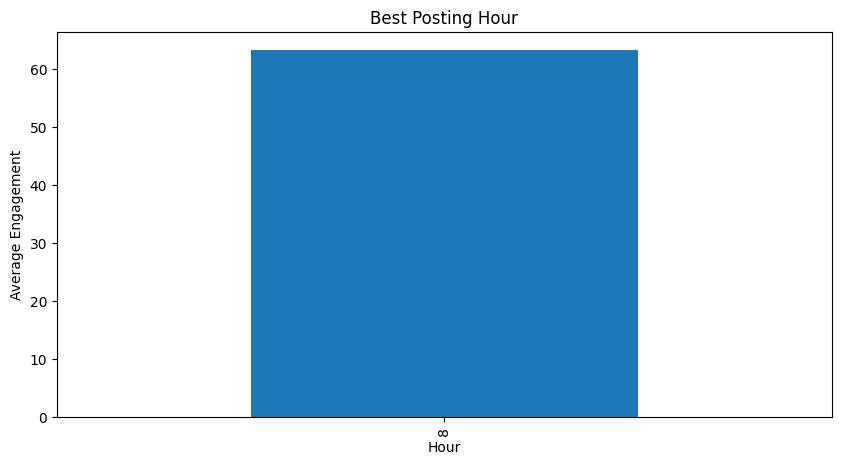

In [19]:
hourly = photo_engagement.groupby('Hour')['engagement'].mean()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
hourly.plot(kind='bar')
plt.title('Best Posting Hour')
plt.ylabel('Average Engagement')
plt.show()

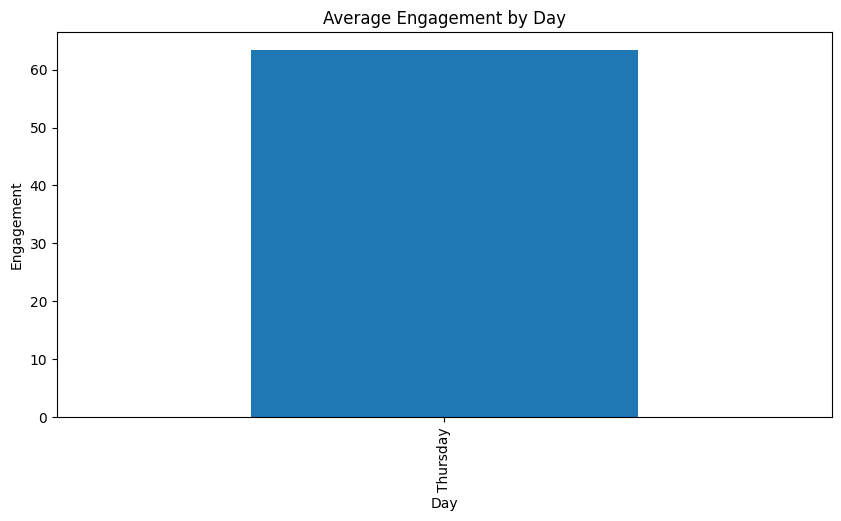

In [20]:
daily = photo_engagement.groupby('Day')['engagement'].mean()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
daily.plot(kind='bar')
plt.title('Average Engagement by Day')
plt.ylabel('Engagement')
plt.show()

In [21]:
tag_usage = photo_tags.groupby('photo').size().reset_index(name='hashtag_count')

tag_usage.head()

,photo,hashtag_count
0,1,5
1,2,4
2,3,1
3,4,4
4,5,4


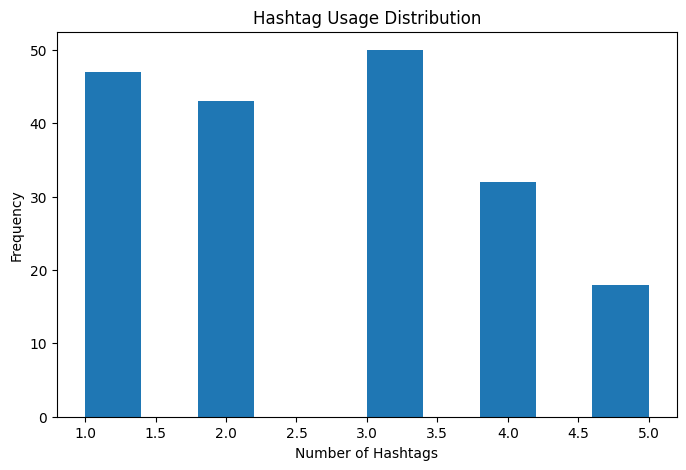

In [22]:
plt.figure(figsize=(8,5))
plt.hist(tag_usage['hashtag_count'])
plt.title('Hashtag Usage Distribution')
plt.xlabel('Number of Hashtags')
plt.ylabel('Frequency')
plt.show()

In [23]:
top_tags = photo_tags.merge(
    tags,
    left_on='tag ID',
    right_on='id'
)

print(top_tags['tag text'].value_counts().head(10))

tag text
smile      59
beach      42
party      39
fun        38
concert    24
food       24
lol        24
hair       23
happy      22
beauty     20
Name: count, dtype: int64


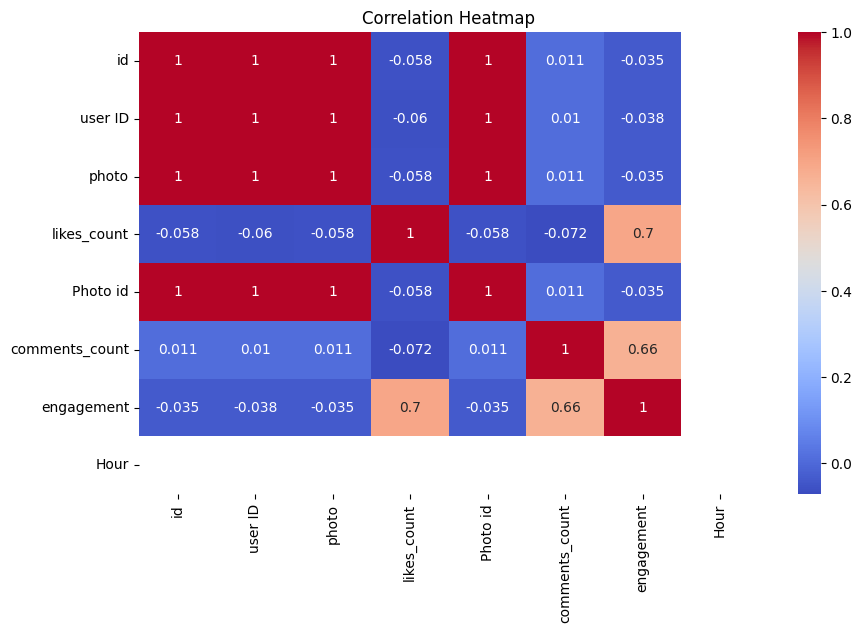

In [24]:
import seaborn as sns
import numpy as np

numeric_cols = photo_engagement.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()